# Diabetes Risk Analysis

This project explores clinical and lifestyle factors associated with diabetes using NHANES data.

The analysis includes:

- data cleaning
- exploratory analysis
- logistic regression
- interpretation of odds ratios

## Data Source

The data used in this project comes from the National Health and Nutrition Examination Survey (NHANES), conducted by the CDC.

NHANES is a large epidemiological study that collects health and nutrition data from the U.S. population.

In this project we will use three datasets:

- Demographics (age, sex, etc.)
- Diabetes questionnaire
- Body measurements (BMI)

In [2]:
import os

os.makedirs("../data", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)
os.makedirs("../src", exist_ok=True)

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

In [4]:
data_path = "../data/"

In [5]:
import os

os.listdir("../data")

['bmi.XPT', 'demographics.XPT', 'diabetes.XPT', 'nhanes_diabetes_clean.csv']

In [6]:
import requests

In [7]:
demographics_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.xpt"
diabetes_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DIQ_J.xpt"
bmi_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.xpt"

In [8]:
def download_file(url, output_path):
    response = requests.get(url)
    response.raise_for_status()

    with open(output_path, "wb") as f:
        f.write(response.content)

    print(f"Downloaded: {output_path}")

In [9]:
download_file(demographics_url, "../data/demographics.XPT")
download_file(diabetes_url, "../data/diabetes.XPT")
download_file(bmi_url, "../data/bmi.XPT")

Downloaded: ../data/demographics.XPT
Downloaded: ../data/diabetes.XPT
Downloaded: ../data/bmi.XPT


In [10]:
for filename in ["demographics.XPT", "diabetes.XPT", "bmi.XPT"]:
    path = os.path.join("../data", filename)
    print(filename, os.path.getsize(path), "bytes")

demographics.XPT 3412720 bytes
diabetes.XPT 3851840 bytes
bmi.XPT 1466000 bytes


In [11]:
demo = pd.read_sas("../data/demographics.XPT", format="xport")
diabetes = pd.read_sas("../data/diabetes.XPT", format="xport")
bmi = pd.read_sas("../data/bmi.XPT", format="xport")

In [12]:
demo.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,3.0,1.0,3.0,9246.491865,8539.731348,2.0,145.0,15.0,15.0,5.00
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,3.0,1.0,2.0,37338.768343,42566.614750,1.0,143.0,15.0,15.0,5.00
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,1.0,2.0,NaN,8614.571172,8338.419786,2.0,145.0,3.0,3.0,0.82
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,3.0,1.0,2.0,8548.632619,8723.439814,2.0,134.0,NaN,NaN,NaN
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,2.0,1.0,3.0,6769.344567,7064.609730,1.0,138.0,10.0,10.0,1.88


In [13]:
diabetes.head()

,SEQN,DIQ010,DID040,DIQ160,DIQ170,DIQ172,DIQ175A,DIQ175B,DIQ175C,DIQ175D,...,DIQ300D,DID310S,DID310D,DID320,DID330,DID341,DID350,DIQ350U,DIQ360,DIQ080
0,93703.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,2.0,NaN,2.0,2.0,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,93706.0,2.0,NaN,2.0,2.0,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,93707.0,2.0,NaN,2.0,2.0,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
bmi.head()

,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,93703.0,1.0,13.7,3.0,89.6,NaN,NaN,NaN,88.6,NaN,...,NaN,NaN,18.0,NaN,16.2,NaN,48.2,NaN,NaN,NaN
1,93704.0,1.0,13.9,NaN,95.0,NaN,NaN,NaN,94.2,NaN,...,NaN,NaN,18.6,NaN,15.2,NaN,50.0,NaN,NaN,NaN
2,93705.0,1.0,79.5,NaN,NaN,NaN,NaN,NaN,158.3,NaN,...,37.0,NaN,36.0,NaN,32.0,NaN,101.8,NaN,110.0,NaN
3,93706.0,1.0,66.3,NaN,NaN,NaN,NaN,NaN,175.7,NaN,...,46.6,NaN,38.8,NaN,27.0,NaN,79.3,NaN,94.4,NaN
4,93707.0,1.0,45.4,NaN,NaN,NaN,NaN,NaN,158.4,NaN,...,38.1,NaN,33.8,NaN,21.5,NaN,64.1,NaN,83.0,NaN


In [15]:
demo.columns.tolist()

['SEQN',
 'SDDSRVYR',
 'RIDSTATR',
 'RIAGENDR',
 'RIDAGEYR',
 'RIDAGEMN',
 'RIDRETH1',
 'RIDRETH3',
 'RIDEXMON',
 'RIDEXAGM',
 'DMQMILIZ',
 'DMQADFC',
 'DMDBORN4',
 'DMDCITZN',
 'DMDYRSUS',
 'DMDEDUC3',
 'DMDEDUC2',
 'DMDMARTL',
 'RIDEXPRG',
 'SIALANG',
 'SIAPROXY',
 'SIAINTRP',
 'FIALANG',
 'FIAPROXY',
 'FIAINTRP',
 'MIALANG',
 'MIAPROXY',
 'MIAINTRP',
 'AIALANGA',
 'DMDHHSIZ',
 'DMDFMSIZ',
 'DMDHHSZA',
 'DMDHHSZB',
 'DMDHHSZE',
 'DMDHRGND',
 'DMDHRAGZ',
 'DMDHREDZ',
 'DMDHRMAZ',
 'DMDHSEDZ',
 'WTINT2YR',
 'WTMEC2YR',
 'SDMVPSU',
 'SDMVSTRA',
 'INDHHIN2',
 'INDFMIN2',
 'INDFMPIR']

In [16]:
diabetes.columns.tolist()

['SEQN',
 'DIQ010',
 'DID040',
 'DIQ160',
 'DIQ170',
 'DIQ172',
 'DIQ175A',
 'DIQ175B',
 'DIQ175C',
 'DIQ175D',
 'DIQ175E',
 'DIQ175F',
 'DIQ175G',
 'DIQ175H',
 'DIQ175I',
 'DIQ175J',
 'DIQ175K',
 'DIQ175L',
 'DIQ175M',
 'DIQ175N',
 'DIQ175O',
 'DIQ175P',
 'DIQ175Q',
 'DIQ175R',
 'DIQ175S',
 'DIQ175T',
 'DIQ175U',
 'DIQ175V',
 'DIQ175W',
 'DIQ175X',
 'DIQ180',
 'DIQ050',
 'DID060',
 'DIQ060U',
 'DIQ070',
 'DIQ230',
 'DIQ240',
 'DID250',
 'DID260',
 'DIQ260U',
 'DIQ275',
 'DIQ280',
 'DIQ291',
 'DIQ300S',
 'DIQ300D',
 'DID310S',
 'DID310D',
 'DID320',
 'DID330',
 'DID341',
 'DID350',
 'DIQ350U',
 'DIQ360',
 'DIQ080']

In [17]:
bmi.columns.tolist()

['SEQN',
 'BMDSTATS',
 'BMXWT',
 'BMIWT',
 'BMXRECUM',
 'BMIRECUM',
 'BMXHEAD',
 'BMIHEAD',
 'BMXHT',
 'BMIHT',
 'BMXBMI',
 'BMXLEG',
 'BMILEG',
 'BMXARML',
 'BMIARML',
 'BMXARMC',
 'BMIARMC',
 'BMXWAIST',
 'BMIWAIST',
 'BMXHIP',
 'BMIHIP']

## Variable Selection

In this analysis, we selected a subset of variables based on clinical relevance and prior knowledge in epidemiology.

The selected variables include:

- Age
- Sex
- Body Mass Index (BMI)
- Diabetes status

### Rationale

These variables were chosen because they are well-established risk factors for type 2 diabetes:

- **Age**: The risk of diabetes increases with age.
- **Sex**: Differences in diabetes prevalence have been observed between males and females.
- **BMI**: Higher BMI is strongly associated with obesity and insulin resistance, which are key drivers of diabetes.

By focusing on these variables, we aim to build a simple and interpretable model that captures key determinants of diabetes risk.

## Study Objective

The objective of this analysis is to investigate the relationship between demographic and clinical factors and the presence of diabetes.

### Hypothesis

We hypothesize that:

- Older individuals have a higher prevalence of diabetes.
- Individuals with higher BMI are more likely to have diabetes.
- There may be differences in diabetes prevalence between males and females.

In [18]:
demo_sub = demo[["SEQN","RIDAGEYR","RIAGENDR"]]
diabetes_sub = diabetes[["SEQN","DIQ010"]]
bmi_sub = bmi[["SEQN","BMXBMI"]]

In [19]:
df = demo_sub.merge(diabetes_sub, on="SEQN", how="inner")
df = df.merge(bmi_sub, on="SEQN", how="inner")

In [20]:
df.head()

,SEQN,RIDAGEYR,RIAGENDR,DIQ010,BMXBMI
0,93703.0,2.0,2.0,2.0,17.5
1,93704.0,2.0,1.0,2.0,15.7
2,93705.0,66.0,2.0,2.0,31.7
3,93706.0,18.0,1.0,2.0,21.5
4,93707.0,13.0,1.0,2.0,18.1


In [21]:
df.shape

(8366, 5)

In [22]:
df = df.rename(columns={
    "RIDAGEYR": "age",
    "RIAGENDR": "sex",
    "DIQ010": "diabetes",
    "BMXBMI": "bmi"
})

In [23]:
df["diabetes"].value_counts(dropna=False)

diabetes
2.0    7334
1.0     853
3.0     175
9.0       4
Name: count, dtype: int64

## Diabetes Variable

The diabetes variable (DIQ010) represents whether a participant has been told by a doctor that they have diabetes.

The distribution of responses is as follows:

- 2 = No diabetes (7334 individuals)
- 1 = Diabetes (853 individuals)
- 3 = Borderline (175 individuals)
- 9 = Unknown (4 individuals)

For this analysis, we focus only on clear cases (Yes/No), excluding borderline and unknown responses.

This ensures a well-defined binary outcome for statistical modeling.

In [24]:
df.isnull().sum()

SEQN          0
age           0
sex           0
diabetes      0
bmi         361
dtype: int64

## Missing Values Analysis

We examined the presence of missing values across the selected variables.

- No missing values were found for age, sex, or diabetes status.
- However, BMI had 361 missing observations.

This is expected in NHANES data, as not all participants complete every examination.

For the purpose of this analysis, individuals with missing BMI values will be excluded from the final dataset.

In [25]:
df = df[df["diabetes"].isin([1,2])]

In [26]:
df["diabetes"] = df["diabetes"].map({1:1, 2:0})

In [27]:
df["sex"].value_counts()

sex
2.0    4178
1.0    4009
Name: count, dtype: int64

## Sex Distribution

The dataset includes both male and female participants:

- Female: 4178
- Male: 4009

The distribution is relatively balanced, which is beneficial for statistical analysis and modeling.

In [28]:
df["sex_label"] = df["sex"].map({1:"male",2:"female"})

In [29]:
df[["age","bmi"]].describe()

,age,bmi
count,8187.000000,7828.000000
mean,35.405032,26.467386
std,24.859200,8.227753
min,1.000000,12.300000
25%,12.000000,20.300000
50%,32.000000,25.700000
75%,58.000000,31.200000
max,80.000000,86.200000


## Age and BMI Summary

Summary statistics for age and BMI:

- Mean age: 35.4 years
- Mean BMI: 26.5

The BMI distribution shows:

- Minimum BMI: 12.3
- Maximum BMI: 86.2

The average BMI falls within the overweight range, which is consistent with population-level trends.

The presence of very high BMI values suggests potential outliers, which will be explored further in the analysis.

## Body Mass Index (BMI)

Body Mass Index (BMI) is a widely used measure to assess body weight relative to height.

It is calculated as:

BMI = weight (kg) / height (m)^2

BMI categories:

- Underweight: < 18.5
- Normal weight: 18.5 – 24.9
- Overweight: 25 – 29.9
- Obesity: ≥ 30

BMI is a key risk factor for many chronic diseases, including type 2 diabetes.

Higher BMI values are strongly associated with increased risk of insulin resistance and metabolic disorders.

In [30]:
df = df.dropna(subset=["age","bmi","sex","diabetes"])

In [31]:
df.to_csv("../data/nhanes_diabetes_clean.csv", index=False)

## Initial Observations

From the initial exploration:

- The dataset is large and relatively complete, with missing values mainly in BMI.
- The prevalence of diabetes is lower compared to non-diabetic individuals, which reflects real-world population distributions.
- BMI values suggest that overweight and obesity are common in the dataset.

These observations motivate further analysis of the relationship between BMI, age, and diabetes risk.

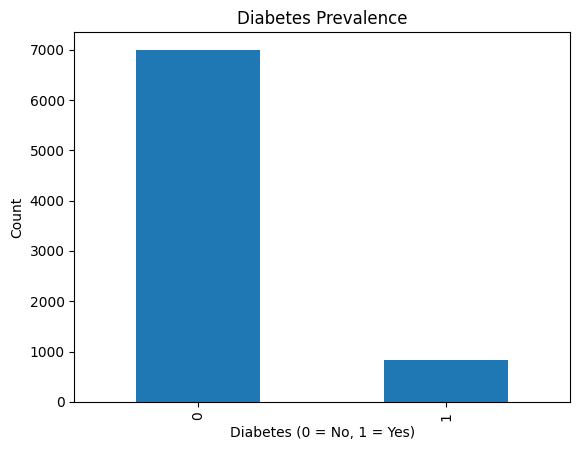

In [32]:
df["diabetes"].value_counts().plot(kind="bar")

plt.title("Diabetes Prevalence")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.savefig("../figures/diabetes_prevalence.png", dpi=300, bbox_inches="tight")
plt.show()

## Diabetes Prevalence

The distribution of diabetes in the dataset shows that most individuals do not have diabetes.

This is expected in a general population sample, where the prevalence of diabetes is typically lower than non-diabetes cases.

However, the presence of a substantial number of diabetes cases allows for meaningful statistical analysis.

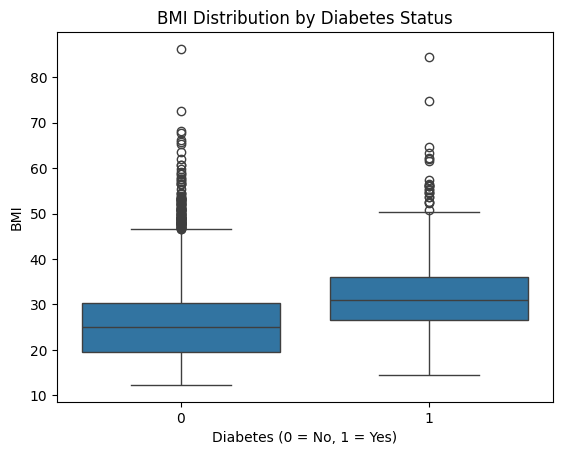

In [33]:
import seaborn as sns

sns.boxplot(x="diabetes", y="bmi", data=df)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("BMI")

plt.savefig("../figures/bmi_vs_diabetes.png", dpi=300, bbox_inches="tight")
plt.show()

## BMI and Diabetes 

The boxplot shows that individuals with diabetes tend to have higher BMI values compared to those without diabetes.

- The median BMI is clearly higher in the diabetic group.
- The entire distribution appears shifted toward higher values.

Outliers are present in both groups, indicating that high BMI values exist among individuals with and without diabetes.

However, the presence of more extreme values in the non-diabetic group may be influenced by the larger sample size in that group.

Therefore, the key observation is not the number of outliers, but the overall upward shift in BMI among individuals with diabetes.

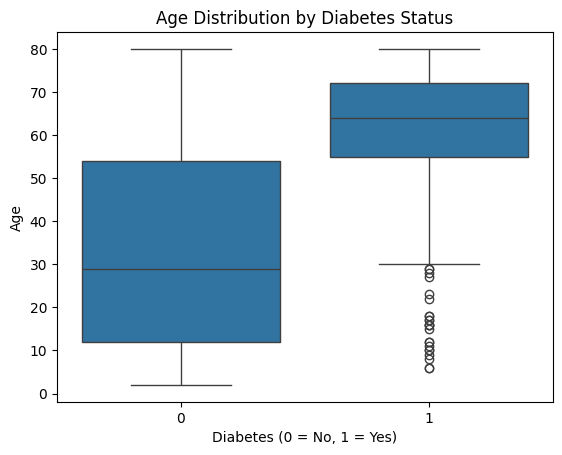

In [34]:
sns.boxplot(x="diabetes", y="age", data=df)

plt.title("Age Distribution by Diabetes Status")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.savefig("../figures/age_vs_diabetes.png", dpi=300, bbox_inches="tight")
plt.show()

## Age and Diabetes

The age distribution differs significantly between individuals with and without diabetes.

- Individuals with diabetes are generally older.
- The median age is substantially higher in the diabetic group.
- Younger individuals are less likely to have diabetes.

This is consistent with epidemiological evidence that diabetes prevalence increases with age.

In [35]:
!pip install statsmodels

In [36]:
import statsmodels.api as sm

In [37]:
X = df[["age", "bmi", "sex"]]
y = df["diabetes"]

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.251964
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:                 7828
Model:                          Logit   Df Residuals:                     7824
Method:                           MLE   Df Model:                            3
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                  0.2560
Time:                        10:30:05   Log-Likelihood:                -1972.4
converged:                       True   LL-Null:                       -2651.2
Covariance Type:            nonrobust   LLR p-value:                4.727e-294
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.7979      0.259    -26.290      0.000      -7.305      -6.291
age            0.0622      0.

In [38]:
import numpy as np

np.exp(result.params)

const    0.001116
age      1.064165
bmi      1.074501
sex      0.672331
dtype: float64

## Logistic Regression Results

A logistic regression model was fitted to evaluate the association between age, BMI, sex, and diabetes.

### Key Findings

- **Age**:  
  Each additional year of age is associated with a 6.4% increase in the odds of diabetes (OR = 1.064).

- **BMI**:  
  Each unit increase in BMI is associated with a 7.4% increase in the odds of diabetes (OR = 1.074).

- **Sex**:  
  Female individuals have approximately 33% lower odds of diabetes compared to males (OR = 0.67).

### Statistical Significance

All variables were highly statistically significant (p < 0.001), indicating strong evidence of association with diabetes.

### Interpretation

These results confirm that:

- Age and BMI are strong risk factors for diabetes.
- Higher BMI significantly increases the likelihood of diabetes.
- There are sex-based differences in diabetes prevalence.

These findings are consistent with established epidemiological evidence.

## Extended Model with Smoking

The model was extended by including smoking status as a behavioral risk factor.

Smoking is a known risk factor for metabolic and cardiovascular diseases, and may also be associated with diabetes risk.

Including smoking allows us to control for potential confounding effects and better isolate the impact of BMI and age on diabetes.

In [39]:
smoking_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/SMQ_J.xpt"

download_file(smoking_url, "../data/smoking.XPT")

Downloaded: ../data/smoking.XPT


In [40]:
smoking = pd.read_sas("../data/smoking.XPT", format="xport")

In [41]:
smoking.columns.tolist()

['SEQN',
 'SMQ020',
 'SMD030',
 'SMQ040',
 'SMQ050Q',
 'SMQ050U',
 'SMD057',
 'SMQ078',
 'SMD641',
 'SMD650',
 'SMD093',
 'SMDUPCA',
 'SMD100BR',
 'SMD100FL',
 'SMD100MN',
 'SMD100LN',
 'SMD100TR',
 'SMD100NI',
 'SMD100CO',
 'SMQ621',
 'SMD630',
 'SMQ661',
 'SMQ665A',
 'SMQ665B',
 'SMQ665C',
 'SMQ665D',
 'SMQ670',
 'SMQ848',
 'SMQ852Q',
 'SMQ852U',
 'SMQ890',
 'SMQ895',
 'SMQ900',
 'SMQ905',
 'SMQ910',
 'SMQ915',
 'SMAQUEX2']

In [42]:
smoking_sub = smoking[["SEQN","SMQ020"]]

In [43]:
df = df.merge(smoking_sub, on="SEQN", how="inner")

In [44]:
df = df.rename(columns={"SMQ020":"smoking"})

In [46]:
df["smoking"].value_counts(dropna=False)

smoking
2.0    3140
1.0    2127
NaN     852
Name: count, dtype: int64

In [47]:
df = df[df["smoking"].isin([1,2])]

In [48]:
df["smoking"] = df["smoking"].map({1:1, 2:0})

In [49]:
df.shape

(5267, 7)

In [50]:
X = df[["age","bmi","sex","smoking"]]
y = df["diabetes"]

X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.357379
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               diabetes   No. Observations:                 5267
Model:                          Logit   Df Residuals:                     5262
Method:                           MLE   Df Model:                            4
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                  0.1717
Time:                        10:35:07   Log-Likelihood:                -1882.3
converged:                       True   LL-Null:                       -2272.6
Covariance Type:            nonrobust   LLR p-value:                1.216e-167
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.8613      0.297    -23.118      0.000      -7.443      -6.280
age            0.0620      0.

In [51]:
import numpy as np
np.exp(result.params)

const      0.001048
age        1.064004
bmi        1.074904
sex        0.679043
smoking    1.101464
dtype: float64

## Extended Model with Smoking

Smoking status was added to the logistic regression model to evaluate its association with diabetes.

### Results

- Smoking showed an odds ratio of 1.10.
- However, the association was not statistically significant (p = 0.259).

### Interpretation

This suggests that, after adjusting for age, BMI, and sex, smoking is not independently associated with diabetes in this dataset.

Possible explanations include:

- The effect of smoking may be mediated through other variables.
- Age and BMI are stronger predictors and may account for most of the variation in diabetes risk.
- The reduced sample size due to missing smoking data may have decreased statistical power.

### Conclusion

While smoking is an important health risk factor, it does not appear to be a significant predictor of diabetes in this model.

## Final Conclusion

In this project, we analyzed the association between demographic and clinical factors and diabetes using NHANES data.

### Key Findings

- **Age** was strongly associated with diabetes, with older individuals showing higher risk.
- **BMI** was a major predictor, with higher BMI significantly increasing the odds of diabetes.
- **Sex** showed a significant association, with females having lower odds compared to males.
- **Smoking** was not significantly associated with diabetes after adjusting for other variables.

### Interpretation

These findings are consistent with known epidemiological evidence that age and obesity are primary risk factors for type 2 diabetes.

The lack of significance for smoking suggests that its effect may be indirect or confounded by other variables.

### Limitations

- Missing data reduced the sample size.
- The analysis is observational and does not imply causality.
- Additional variables such as physical activity or diet were not included.

### Conclusion

This analysis demonstrates how real-world health data can be used to identify key risk factors for chronic diseases and highlights the importance of proper data cleaning and statistical modeling in biomedical research.